# This is for 6 mL : 4 mL ratio in room temperature, 2.18mM concentration

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Temperature vs Time

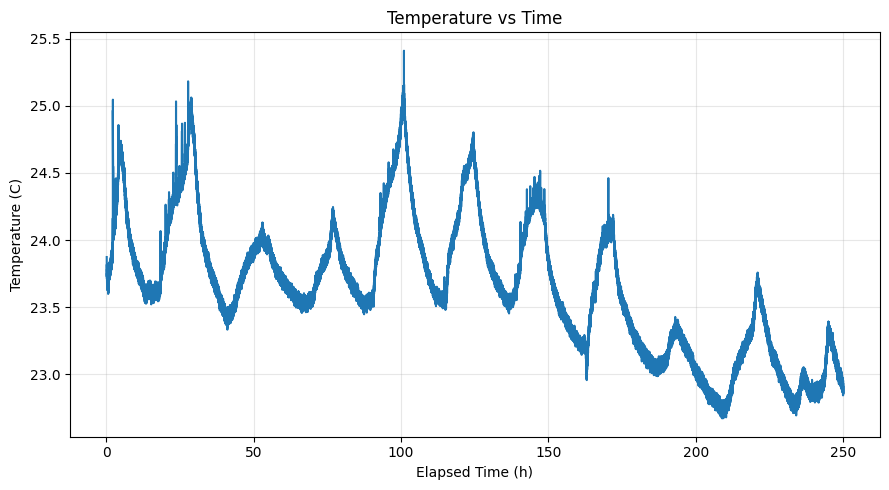

In [4]:
main_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M1_2.5mM_pressure_RT_o2_release.csv"
df_main = pd.read_csv(main_csv)
df_main.columns = [c.strip() for c in df_main.columns]
temperature_col = "calibrated temperature (C)"
time_col = "Time (s)"

t_h = pd.to_numeric(df_main[time_col], errors="coerce")
plt.figure(figsize=(9,5))
plt.plot(t_h, df_main[temperature_col], label="Temperature (C)")
plt.xlabel("Elapsed Time (h)")
plt.ylabel("Temperature (C)")
plt.title("Temperature vs Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Pressure in atm

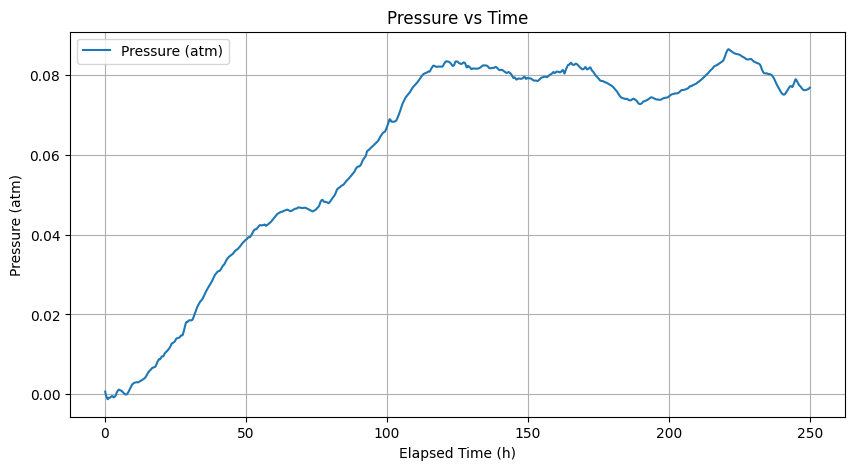

0.08648617819231443


In [5]:
main_csv =   r"C:\Users\chand\Documents\GitHub\Thesis\M1_2.5mM_pressure_RT_o2_release.csv"

df_main = pd.read_csv(main_csv)

df_main.columns = [c.strip() for c in df_main.columns]


pressure_col = df_main["DWT denoised pressure (kPa)"] / 101.325  # convert kPa to atm
time_col = df_main["Time (s)"] 

plt.figure(figsize=(10, 5))
plt.plot(time_col, pressure_col, label="Pressure (atm)")
plt.xlabel("Elapsed Time (h)")
plt.ylabel("Pressure (atm)")
plt.title("Pressure vs Time")
plt.legend()
plt.grid()
plt.show()

print(max(pressure_col))

# Calculating Delta H with reference

In [8]:
import pandas as pd
from pathlib import Path
import numpy as np

# ====== user inputs ======
csv_path  = r"C:\Users\chand\Documents\GitHub\Thesis\M1_2.5mM_pressure_RT_o2_release.csv"
temp_col  = "calibrated temperature (C)"   
# =========================

# Eq. (11) coefficients for O2 in water (<348 K)
A1 = 83.91236
A2 = 23.24323
R = 8.314462618  # J·mol^-1·K^-1

def deltaH_J_per_mol(T_K: pd.Series) -> pd.Series:
    """
    ΔH°(T) = R * (A2*T - 100*A1)  [J/mol]
    (Since A3 = A4 = 0 for this temperature range.)
    """
    return R * (A2 * T_K - 100.0 * A1)

# --- load & clean ---
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]
T_C_orig = pd.to_numeric(df[temp_col], errors="coerce").dropna().reset_index(drop=True)

# --- round °C to 2 decimals, convert to K ---
T_C_round2 = T_C_orig.round(2)
T_K_from_round = T_C_round2 + 273.15

# --- compute ΔH ---
dH_Jmol  = deltaH_J_per_mol(T_K_from_round)
dH_kJmol = dH_Jmol / 1000.0

# --- assemble output table ---
out = pd.DataFrame({
    "T_C_original": T_C_orig,
    "T_C_rounded_2dp": T_C_round2,
    "T_K_from_rounded": T_K_from_round,
    "DeltaH_kJ_per_mol": dH_kJmol
})

# --- save ---
out_path = Path(csv_path).with_name(Path(csv_path).stem + "RT_DeltaH_from_T.csv")
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(out.head(8).to_string(index=False))

Saved: C:\Users\chand\Documents\GitHub\Thesis\M1_2.5mM_pressure_RT_o2_releaseRT_DeltaH_from_T.csv
 T_C_original  T_C_rounded_2dp  T_K_from_rounded  DeltaH_kJ_per_mol
    23.873761            23.87            297.02         -12.368028
    23.843792            23.84            296.99         -12.373825
    23.793824            23.79            296.94         -12.383488
    23.833855            23.83            296.98         -12.375758
    23.848886            23.85            297.00         -12.371893
    23.863916            23.86            297.01         -12.369960
    23.813948            23.81            296.96         -12.379623
    23.833978            23.83            296.98         -12.375758


# Calculating KH from delta H

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path

# ===== inputs =====
# CSV produced in the previous step (with T_K_from_rounded + DeltaH_kJ_per_mol)
dh_csv_path = r"C:\Users\chand\Documents\GitHub\Thesis\M1_2.5mM_pressure_RT_o2_releaseRT_DeltaH_from_T.csv"
tempK_col   = "T_K_from_rounded"      # Kelvin (from rounded °C)
dH_col      = "DeltaH_kJ_per_mol"     # kJ/mol
tempC_col   = "T_C_original"    # optional; for reference only



T_REF_K     = 298.15                  # K
kH_ref_atm  = 1.30e-3                 # mol·L^-1·atm^-1 at 297.15 K
R_J         = 8.314462618             # J·mol^-1·K^-1
# ==================

# Load ΔH data
df = pd.read_csv(dh_csv_path)
TK = pd.to_numeric(df[tempK_col], errors="coerce")
dH_kJmol = pd.to_numeric(df[dH_col], errors="coerce")
tempC = pd.to_numeric(df.get(tempC_col, pd.Series([])), errors="coerce")

# van’t Hoff: kH(T) = kH_ref * exp( -(ΔH/R)*(1/T - 1/T_ref) )
dH_Jmol = dH_kJmol * 1000.0
ln_ratio = -dH_Jmol / R_J * (1.0/TK - 1.0/T_REF_K)
kH_T_atm = kH_ref_atm * np.exp(ln_ratio)   # mol·L^-1·atm^-1

# Build output table
out = pd.DataFrame({
    "Temperature_K": TK,
    "DeltaH_kJ_per_mol": dH_kJmol,
    "kH_mol_per_L_atm": kH_T_atm,
    "calibrated temperature (C)" : tempC
})

# Save
out_path = Path("henrys_constants_RT.csv")
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(out.head().to_string(index=False))


Saved: henrys_constants_RT.csv
 Temperature_K  DeltaH_kJ_per_mol  kH_mol_per_L_atm  calibrated temperature (C)
        297.02         -12.368028          0.001325                   23.873761
        296.99         -12.373825          0.001326                   23.843792
        296.94         -12.383488          0.001327                   23.793824
        296.98         -12.375758          0.001326                   23.833855
        297.00         -12.371893          0.001325                   23.848886


# Behaviour profile of KH with respect to time and temperature at RT

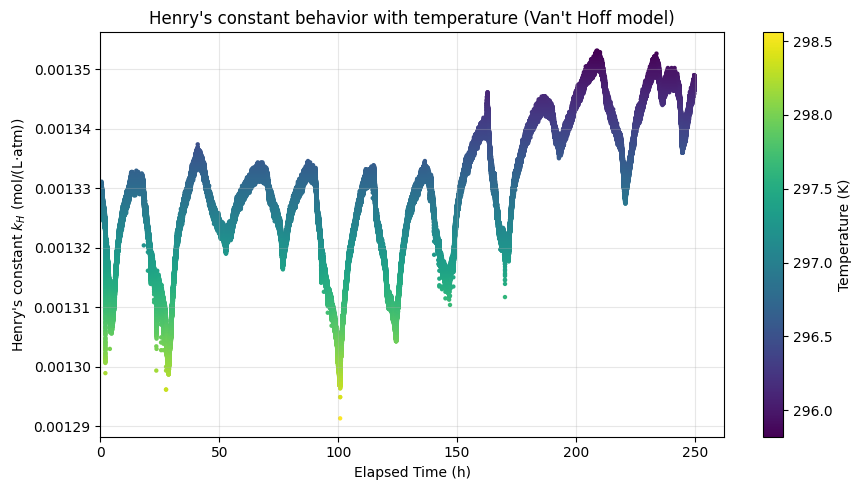

In [15]:

# Behaviour profile of KH with respect to time and temperature



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- paths ---
main_csv_path  = r"C:\Users\chand\Documents\GitHub\Thesis\M1_2.5mM_pressure_RT_o2_release.csv"
side_csv_path = r"C:\Users\chand\Documents\GitHub\Thesis\2.5mM EDA\henrys_constants_RT.csv"

henry_values  = "kH_mol_per_L_atm"

time_col      = "Time (s)"
T_K           = "Temperature_K"  


# Load data
df_main = pd.read_csv(main_csv_path)
df_main.columns = [c.strip() for c in df_main.columns]

df_side = pd.read_csv(side_csv_path)
df_side.columns = [c.strip() for c in df_side.columns]

# Parse columns
t_h   = pd.to_numeric(df_main[time_col], errors="coerce")
k_h   = pd.to_numeric(df_side[henry_values], errors="coerce")
t_k   = pd.to_numeric(df_side[T_K], errors="coerce")

# Ensure same length
n = min( len(t_h), len(k_h), len(t_k))
t_h, k_h, t_k = [s.iloc[:n].reset_index(drop=True) for s in (t_h, k_h, t_k)]
t_h = t_h - t_h.iloc[0]  # start at 0 h

# Plot kH over time, color-coded by temperature
plt.figure(figsize=(9, 5))
sc = plt.scatter(t_h, k_h, c=t_k, cmap='viridis', s=10, edgecolors='none')
cbar = plt.colorbar(sc)
cbar.set_label("Temperature (K)")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Henry's constant $k_H$ (mol/(L·atm))")
plt.title("Henry's constant behavior with temperature (Van't Hoff model)")
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.tight_layout()
plt.show()


# Headspace o2 detected by sensor

### The headspace o2 column in the csv is not accurate, the recalculated value is stored in    [] .csv

In [17]:
import pandas as pd

# ---------- Constants ----------
R = 0.082057  # L⋅atm/(mol⋅K)
V_headspace = 0.004

input_csv =   r"C:\Users\chand\Documents\GitHub\Thesis\M1_2.5mM_pressure_RT_o2_release.csv"
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\2.5mM EDA\henrys_constants_RT.csv"
df = pd.read_csv(input_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

# Extract data
pressure_kpa = pd.to_numeric(df["DWT denoised pressure (kPa)"], errors="coerce")
temp = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")
pressure_atm = pressure_kpa / 101.325

# Create output dataframe starting with original data
df_output = df.copy()


n_o2_mol = (pressure_atm * V_headspace) / (R * temp)
n_o2_umol = n_o2_mol * 1e6
    
# Create column name with volume in mL
column_name = f"O2 Released (µmol) - Vg={V_headspace*1000:.1f}mL"
df_output[column_name] = n_o2_umol

# Save to CSV
output_csv = "O2_RT_released_multi_volumes.csv"
df_output.to_csv(output_csv, index=False)

print(f"Saved to: {output_csv}")

Saved to: O2_RT_released_multi_volumes.csv


# Plotting headspace O2 



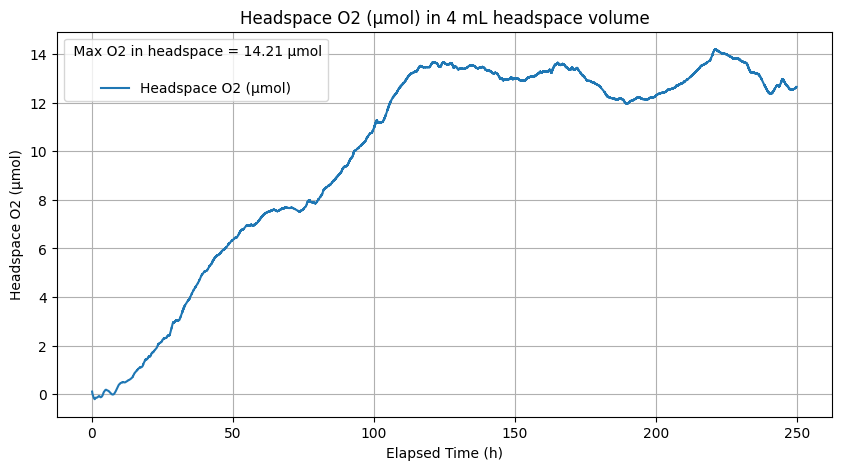

14.206281916026612


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



main_csv = r"C:\Users\chand\Documents\GitHub\Thesis\2.5mM EDA\O2_RT_released_multi_volumes.csv"
df_main = pd.read_csv(main_csv)
df_main.columns = [c.strip() for c in df_main.columns]


headspace_oxygen = df_main["O2 Released (µmol) - Vg=4.0mL"]
time_col = df_main["Time (s)"] 



plt.figure(figsize=(10, 5))
plt.plot(time_col, headspace_oxygen, label="Headspace O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.ylabel("Headspace O2 (µmol)")
plt.title("Headspace O2 (µmol) in 4 mL headspace volume")


# Add small legend box with approach descriptions
legend_text = (
    " Max O2 in headspace = {:.2f} µmol\n"
).format(max(headspace_oxygen))
plt.legend(title=legend_text)
plt.grid()
plt.show()

print(max(headspace_oxygen))

# Dissolved O2 

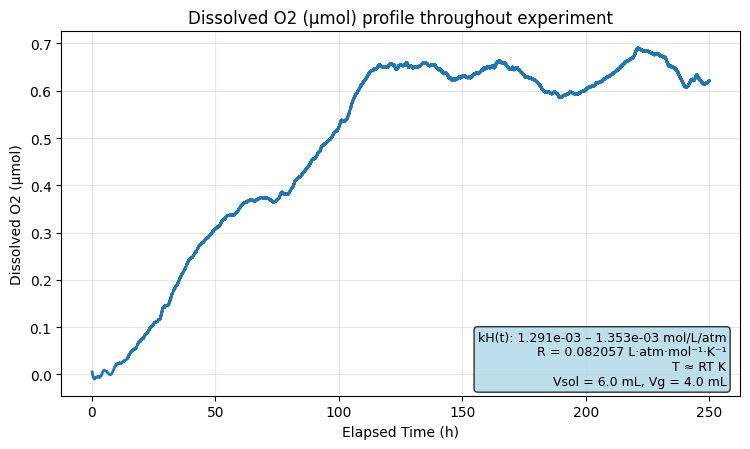

0.6906959896602274
0.6217445838290278


In [20]:
#code for dissolved o2


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   =  r"C:\Users\chand\Documents\GitHub\Thesis\M1_2.5mM_pressure_RT_o2_release.csv"
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\2.5mM EDA\henrys_constants_RT.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1

Vsol = 0.006            # L
Vg   = 0.004            # L

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]



time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm


n_aq_umol = (kH_time * Vsol * p_atm) * 1e6    # dissolved O2 from Henry (µmol)

# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_kpa (kPa)": p_kpa,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_aq (µmol)": n_aq_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_aq (µmol)"], linewidth=2)
plt.ylabel("Dissolved O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Dissolved O2 (µmol) profile throughout experiment")

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ RT K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(max(n_aq_umol))
print(n_aq_umol.iloc[-1])

# Comparison between headspace oxygen and dissolved oxygen

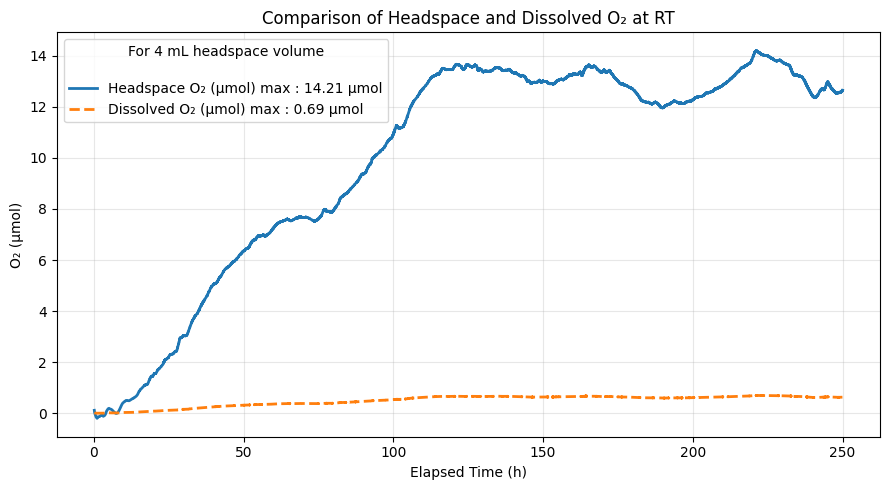

Max Headspace O2: 14.21 µmol
Max Dissolved O2: 0.69 µmol


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
headspace_csv = r"C:\Users\chand\Documents\GitHub\Thesis\2.5mM EDA\O2_RT_released_multi_volumes.csv"
dissolved_main_csv =  r"C:\Users\chand\Documents\GitHub\Thesis\M1_2.5mM_pressure_RT_o2_release.csv"  
kh_csv =r"C:\Users\chand\Documents\GitHub\Thesis\2.5mM EDA\henrys_constants_RT.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057   # L·atm·mol^-1·K^-1
Vsol = 0.006   # L
Vg   = 0.004   # L

# ---------- load headspace ----------
df_hs = pd.read_csv(headspace_csv)
df_hs.columns = [c.strip() for c in df_hs.columns]

time_hs = pd.to_numeric(df_hs["Time (s)"], errors="coerce")
headspace_oxygen = pd.to_numeric(df_hs["O2 Released (µmol) - Vg=4.0mL"], errors="coerce")

# ---------- load dissolved ----------
df_main = pd.read_csv(dissolved_main_csv)
df_main.columns = [c.strip() for c in df_main.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

time_ds = pd.to_numeric(df_main[time_col], errors="coerce")
p_kpa = pd.to_numeric(df_main[press_col], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
p_atm = p_kpa / 101.325    # convert kPa to atm

n_aq_umol = (kH_time * Vsol * p_atm) * 1e6    # dissolved O2 from Henry (µmol)

# ---------- plot both ----------
plt.figure(figsize=(9, 5))
plt.plot(time_hs, headspace_oxygen, label="Headspace O₂ (µmol) max : {:.2f} µmol".format(headspace_oxygen.max()), linewidth=2)
plt.plot(time_ds, n_aq_umol, label="Dissolved O₂ (µmol) max : {:.2f} µmol".format(n_aq_umol.max()), linewidth=2, linestyle="--")

legend_text = (
    "For 4 mL headspace volume\n"
)
plt.legend(title=legend_text)
# labels and formatting
plt.xlabel("Elapsed Time (h)")
plt.ylabel("O₂ (µmol)")
plt.title("Comparison of Headspace and Dissolved O₂ at RT")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max Headspace O2: {headspace_oxygen.max():.2f} µmol")
print(f"Max Dissolved O2: {n_aq_umol.max():.2f} µmol")

# Comparing total oxygen released with dissolved oxygen and headspace oxygen :

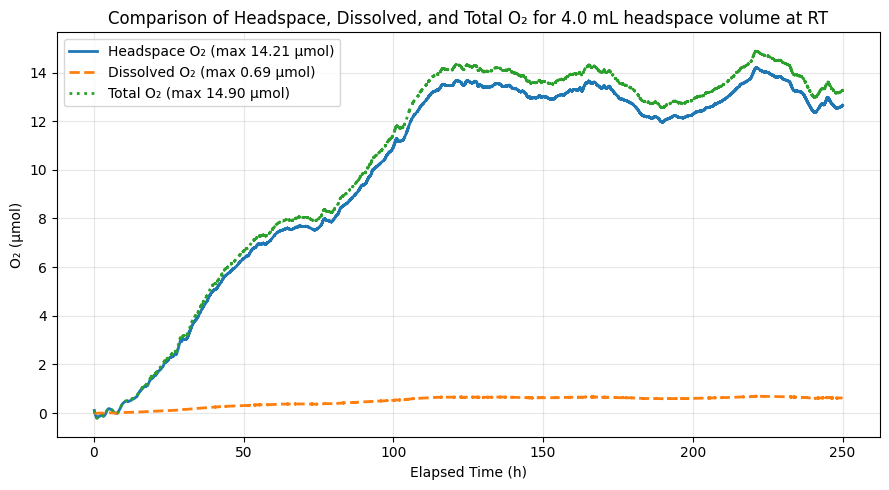

Final Headspace O₂: 12.65 µmol
Final Dissolved O₂: 0.62 µmol
Final Total O₂: 13.28 µmol


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




headspace_csv = r"C:\Users\chand\Documents\GitHub\Thesis\2.5mM EDA\O2_RT_released_multi_volumes.csv"
dissolved_main_csv =  r"C:\Users\chand\Documents\GitHub\Thesis\M1_2.5mM_pressure_RT_o2_release.csv"  
kh_csv =r"C:\Users\chand\Documents\GitHub\Thesis\2.5mM EDA\henrys_constants_RT.csv"

time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057   # L·atm·mol^-1·K^-1
Vsol = 0.006   # L
Vg   = 0.004   # L


# ---------- load headspace ----------
df_hs = pd.read_csv(headspace_csv)
df_hs.columns = [c.strip() for c in df_hs.columns]

time_hs = pd.to_numeric(df_hs["Time (s)"], errors="coerce")
headspace_oxygen = pd.to_numeric(df_hs["O2 Released (µmol) - Vg=4.0mL"], errors="coerce")

# ---------- load dissolved ----------
df_main = pd.read_csv(dissolved_main_csv)
df_main.columns = [c.strip() for c in df_main.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

time_ds = pd.to_numeric(df_main[time_col], errors="coerce")
p_kpa = pd.to_numeric(df_main[press_col], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
p_atm = p_kpa / 101.325    # convert kPa to atm

n_aq_umol = (kH_time * Vsol * p_atm) * 1e6    # dissolved O2 from Henry (µmol)

# ---------- align time if necessary ----------
n = min(len(time_hs), len(headspace_oxygen), len(time_ds), len(n_aq_umol))
time = time_hs.iloc[:n].reset_index(drop=True)
headspace_oxygen = headspace_oxygen.iloc[:n].reset_index(drop=True)
n_aq_umol = n_aq_umol.iloc[:n].reset_index(drop=True)

# ---------- total O2 ----------
n_total_umol = headspace_oxygen + n_aq_umol

plt.figure(figsize=(9, 5))
plt.plot(time, headspace_oxygen, label=f"Headspace O₂ (max {headspace_oxygen.max():.2f} µmol)", linewidth=2)
plt.plot(time, n_aq_umol, label=f"Dissolved O₂ (max {n_aq_umol.max():.2f} µmol)", linewidth=2, linestyle="--")
plt.plot(time, n_total_umol, label=f"Total O₂ (max {n_total_umol.max():.2f} µmol)", linewidth=2, linestyle=":")

plt.legend(loc="upper left")


plt.xlabel("Elapsed Time (h)")
plt.ylabel("O₂ (µmol)")
plt.title("Comparison of Headspace, Dissolved, and Total O₂ for 4.0 mL headspace volume at RT")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




print(f"Final Headspace O₂: {headspace_oxygen.iloc[-1]:.2f} µmol")
print(f"Final Dissolved O₂: {n_aq_umol.iloc[-1]:.2f} µmol")
print(f"Final Total O₂: {n_total_umol.iloc[-1]:.2f} µmol")


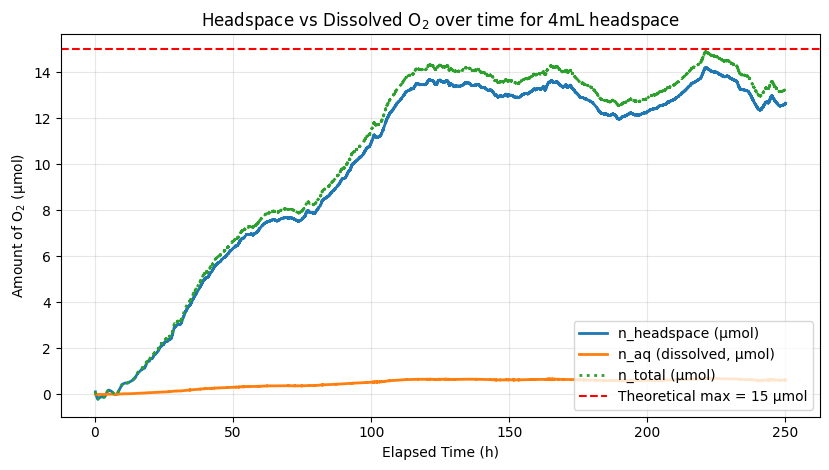

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"C:\Users\chand\Documents\GitHub\Thesis\2.5mM EDA\O2_RT_released_multi_volumes.csv"
kh_csv =r"C:\Users\chand\Documents\GitHub\Thesis\2.5mM EDA\henrys_constants_RT.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.004            # L
n_theory = 15        # µmol (theoretical maximum O2)

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]


T_time  = pd.to_numeric(df_kh["Temperature_K"],    errors="coerce")
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm

n_headspace = pd.to_numeric(df["O2 Released (µmol) - Vg=4.0mL"], errors="coerce")

# Dissolved O2 from Henry’s law (µmol)
n_aq_umol = (kH_time * Vsol * p_atm) * 1e6


n_total_umol = n_headspace + n_aq_umol

# ---- Plot both on one figure ----
plt.figure(figsize=(8.4, 4.8))
plt.plot(time_h, n_headspace, lw=2, label="n_headspace (µmol)")
plt.plot(time_h, n_aq_umol, lw=2, label="n_aq (dissolved, µmol)")
plt.plot(time_h, n_total_umol, lw=2, label="n_total (µmol)", linestyle=":")
plt.axhline(n_theory, ls="--", c="red", lw=1.5, label=f"Theoretical max = {n_theory} µmol")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Amount of O$_2$ (µmol)")
plt.title("Headspace vs Dissolved O$_2$ over time for 4mL headspace")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_headspace (µmol)": n_headspace,
    "n_aq (µmol)": n_aq_umol,
    "n_total (µmol)": n_total_umol
})


# Comparison of total oxygen released (dissolved + headspace) plot with theoretical max 15 umol

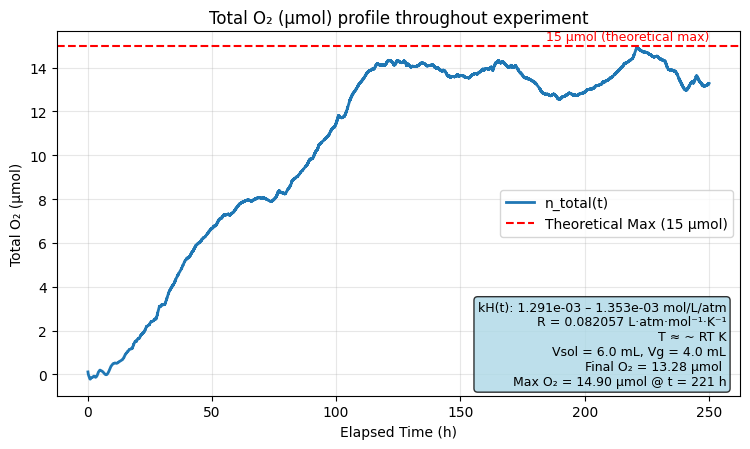

Final Total O₂: 13.28 µmol at time 250.00 h
max o2 at 14.90 µmol at time 221.25 h


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"C:\Users\chand\Documents\GitHub\Thesis\2.5mM EDA\O2_RT_released_multi_volumes.csv"   
kh_csv =r"C:\Users\chand\Documents\GitHub\Thesis\2.5mM EDA\henrys_constants_RT.csv"  
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.004            # L
n_theory = 15       # µmol (theoretical maximum O2)

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]
T_time  = pd.to_numeric(df_kh["Temperature_K"],    errors="coerce")
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm

# ---------- calculate n_total ----------
def calculate_n_total(p_atm, Vg, Vsol, R, T, KH):
    ntot = p_atm * ((Vg / (R*T)) + (KH * Vsol))
    return ntot * 1e6  # µmol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, T_time, kH_time)

# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total (µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total (µmol)"], linewidth=2, label="n_total(t)")
plt.axhline(y=n_theory, color="red", linestyle="--", linewidth=1.5, label="Theoretical Max (15 µmol)")

# Put label near the top-right corner
plt.text(df_out["Elapsed Time (h)"].max(), n_theory+0.1,
         f"{n_theory} µmol (theoretical max)", color="red",
         ha="right", va="bottom", fontsize=9)

plt.ylabel("Total O₂ (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O₂ (µmol) profile throughout experiment")
plt.legend()

# Info box
kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~ RT K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f"Final O₂ = {ntot_umol.iloc[-1]:.2f} µmol \n"
    f" Max O₂ = {ntot_umol.max():.2f} µmol @ t = {time_h[ntot_umol.idxmax()]:.0f} h"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Total O₂: {ntot_umol.iloc[-1]:.2f} µmol at time {time_h.iloc[-1]:.2f} h")
print(f"max o2 at {ntot_umol.max():.2f} µmol at time {time_h[ntot_umol.idxmax()]:.2f} h")

# To save the ntotal umol into a csv file (for pressure predictor) 

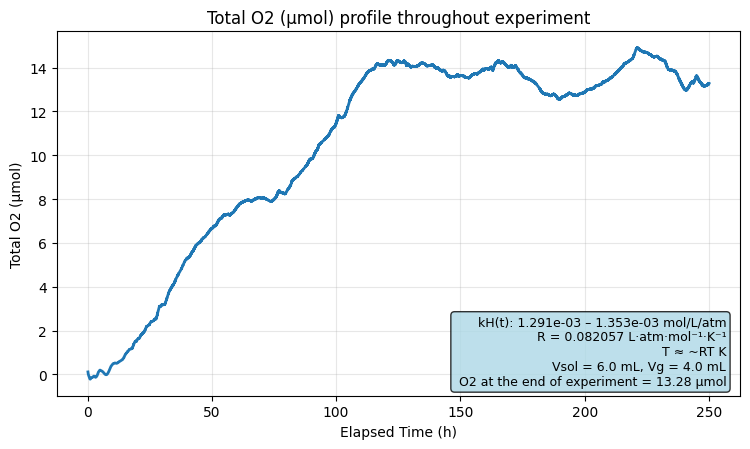

 Saved ntotal data to ntotal_output_RT_2.5mM.csv


In [28]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"C:\Users\chand\Documents\GitHub\Thesis\2.5mM EDA\O2_RT_released_multi_volumes.csv"
kh_csv =r"C:\Users\chand\Documents\GitHub\Thesis\2.5mM EDA\henrys_constants_RT.csv"
# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.004            # L

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]



time_h = pd.to_numeric(df["Time (s)"], errors="coerce")
p_kpa  = pd.to_numeric(df["DWT denoised pressure (kPa)"], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
temp = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")



p_atm = p_kpa / 101.325    # convert kPa to atm




def calculate_n_total (p_kpa: pd.Series, Vg: float, Vsol: float, R: float, T: float, KH: float) -> pd.Series:
    ntot = p_atm * ( (Vg / (R*T)) + (KH * Vsol)) 
    ntot_umol = ntot * 1e6  # Convert to µmol
    return ntot_umol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, temp, kH_time)



# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total(µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total(µmol)"], linewidth=2)
plt.ylabel("Total O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O2 (µmol) profile throughout experiment")

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~RT K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f" O2 at the end of experiment = {ntot_umol.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- save to CSV ----------
output_csv = r"ntotal_output_RT_2.5mM.csv"
df_out.to_csv(output_csv, index=False)
print(f" Saved ntotal data to {output_csv}")